# Instacart Market Basket Analysis

## Importing the required libraries

In [1]:
# Import the libraries you'll need for this analysis
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load the datasets
# Note: These files use semicolon (;) as the separator instead of comma
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')
departments = pd.read_csv('/datasets/departments.csv', sep=';')
aisles = pd.read_csv('/datasets/aisles.csv', sep=';')
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

## Analyze your data

In the cells below, display the datasets using `.info()` and `.head()` to gain insights into their structure and content.

- `.info()`: Provides a concise summary of the dataset, including the data types, non-null counts, and memory usage.
- `.head()`: Displays the first few rows of the dataset, offering a quick overview of the data values.

In [3]:
# In this cell, type "orders" below this line and execute the cell
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [4]:
# In this cell, type "products" below this line and execute the cell
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [5]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [6]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [7]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


Repeat this process for each dataset to understand the structure, including the types of columns and rows they contain. Add additional code cells as needed for your analysis.

In [8]:
# In this cell, type "orders.info() below this line and execute the cell
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [9]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [10]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [11]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


The "Non-Null Count" column provides information about any missing values in each column of the dataset. With a total of 478,952 entries, observe any columns where the non-null count is less than this number to identify missing values.

In [12]:
# In this cell, run orders_products.info() below, but include the argument show_counts=True since this is a large file.
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


Repeat the use of .info() on the remaining datasets to identify missing values and understand their structure. Check the "Non-Null Count" for each dataset to spot any columns with missing values.

## Find and Remove Missing Values

We noticed that some columns contain missing values.

Here are some useful code snippets:

```python
# Identify missing values in each column
print(dataset.isnull().sum())

# Display rows where a specific column has missing values
print(dataset[dataset['column_name'].isna()])

# Confirm no missing values remain
print(dataset.isnull().sum())
```

### `products` Data Frame

We will begin by addressing the missing values in the `products` data frame.

In [13]:
# Display rows where the product_name column has missing values
print(products[products['product_name'].isna()])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


I used the products dataframe to filter for specifics rows in the product_name column 
that are NaN using .isna, identifying NaN values in the product_name column associate with aisle_id being 100 and department_id being 21.

It seems suspicious that all rows with missing `product_name` might be associated with `aisle_id` 100 and `department_id` 21. Let’s verify this by checking if any rows with missing `product_name` have an `aisle_id` different from 100 and 21. This will help us confirm if the issue is isolated to this aisle or spread across others.

In [14]:
# Combine conditions to check for missing product names in aisles other than 100
print(products[(products['product_name'].isna())
      & ~(products['aisle_id'] == 100)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


I used two conditions to see if there was any other product_name NaN values that don't have the value of 100 for aisle_id.

In [15]:
# Combine conditions to check for missing product names in aisles other than 21
print(products[(products['product_name'].isna())
      & ~(products['department_id'] == 21)])

Empty DataFrame
Columns: [product_id, product_name, aisle_id, department_id]
Index: []


I used two conditions to see if there was any other product_name NaN values that don't have the value of 21 for department_id.

To better understand the missing product_name values, let’s determine what department_id 21 and aisle_id 100 represent by referencing the departments and aisles tables.

In [16]:
# What is this aisle and department?
print(departments[departments['department_id'] == 21])
print(aisles[aisles['aisle_id'] == 100])

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


I displayed the rows associated with department_id equal to 21 and aisle_id equal to 100 in the departments and aisles dataframe. Finding the department and aisle columns that match the ids are both missing values.

In [17]:
# Fill missing product names with 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
print(products['product_name'].isnull().sum())

0


Fillna was used to replace all the NaN values with unknown, then checked for any missing values in the product_name column using isnull and sum.

### `orders` data frame

Now let's fill in missing values from the `orders` table.

In [18]:
# Display rows where the days_since_prior_order column has missing values
print(orders[orders['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

I displayed all the rows in the orders dataframe where there is a NaN value in the days_since_prior_order column using isna.

In [19]:
# Are there any missing values where it's not a customer's first order?
print(orders[(orders['days_since_prior_order'].isna())
      & ~(orders['order_number'] == 1)])

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


I filtered the orders dataframe to check if there is any rows in the days_since_prior_order column with NaN values that has an order_number other than 1.

All of the missing `'days_since_prior_order'` values correspond to a customer's first ever order. This makes sense because there is no prior order! We'll leave the values as `NaN` so the column can remain numeric. Also, the `NaN` values shouldn't interfere with any calculations we might do using this column.

### `order_products` data frame

Now let's fill in missing values from the order_products table.

In [20]:
# Display rows where the add_to_cart_order column has missing values
print(order_products[order_products['add_to_cart_order'].isna()])

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


I displayed the order_products dataframe where the column add_to_cart_order has NaN values using isna.

In [21]:
# Use .min() and .max() to find the minimum and maximum values for this column.
print(order_products['add_to_cart_order'].min())
print(order_products['add_to_cart_order'].max())

1.0
64.0


I used the min and max functions to display the total range in the order_products dataframe for the add_to_cart_order column.

In [22]:
# Save all order IDs with at least one missing value in 'add_to_cart_order'
order_ids = order_products[order_products['add_to_cart_order'].isna(
)]['order_id']
print(order_ids)

737        2449164
9926       1968313
14394      2926893
16418      1717990
30114      1959075
            ...   
4505662    1800005
4511400    1633337
4517562     404157
4534112    1673227
4535739    1832957
Name: order_id, Length: 836, dtype: int64


I created a variable called order_ids that contains the order_id column in rows that the add_to_cart_order is a NaN value, then printed the variable.

In [23]:
# Do all orders with missing values have more than 64 products?
print(order_products[order_products['order_id'].isin(
    order_ids)].groupby('order_id').size())

order_id
9310        65
61355      127
102236      95
129627      69
165801      70
          ... 
2999801     70
3125735     86
3308010    115
3347453     71
3383594     69
Length: 70, dtype: int64


I used the isin function to match values from the order_ids variable with the order_products dataframe column order_id, then grouped the data based on the order_id using the size function to determine how many products the order_id contained. Based on the results all add_to_cart_order NaN values have more than 65 products.

In [24]:
# Replace missing values with 999 and convert column to integer type
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(
    '999').astype('int')

I used fillna to replace all NaN values in the add_to_cart_order column to 999 and used astype to make the string 999 into a integer.

For some reason, any item placed in the cart 65th or later has a missing value in the `'add_to_cart_order'` column. Maybe the data type of that column in the database could only hold integer values from 1 to 64. We've decided to replace the missing values with a code value, 999, that represents an unknown placed in cart order above 64. We also converted the column to integer data type. We just need to be careful to remember this if we perform calculations using this column during our analysis.

Other sensible code values we could've used are 0 or -1 because they don't show up elsewhere in the dataset and they don't have any real physical meaning for this variable.

Also note that, for orders with exactly 65 items, we could replace the missing value with 65. But we're going to neglect that for now since we can't determine the 65th item for all orders with 66 items or more.

## Find and Remove Duplicate Values from All the Datasets

Each dataset may contain duplicate rows, which can lead to redundancy and affect the accuracy of our analysis. To handle this:

1. Use the `.duplicated()` method to identify duplicate rows. This method returns a Boolean series where `True` indicates a duplicate row.
2. Apply the `.drop_duplicates()` method to remove these duplicate rows, ensuring a cleaner dataset.
3. Optionally, you can set the `keep` parameter in `.drop_duplicates()` to specify which duplicate to retain (`'first'` or `'last'`).

Here is some example code for reference:
```python
# Check for duplicates
print(dataset.duplicated().sum())  # Number of duplicate rows

# View duplicate rows
print(dataset[dataset.duplicated()]

# Remove duplicates
dataset = dataset.drop_duplicates().reset_index(drop=True)

# Confirm removal
print(dataset.duplicated().sum())  # Should return 0
```

Repeat this process for all datasets to ensure they are free of duplicate rows.

### `orders` data frame

In [25]:
# Find the number of duplicate rows in the orders dataframe
print(orders.duplicated().sum())

15


I used the duplicated and sum function on the orders dataframe to identify the total number of duplicate rows.

In [26]:
# View the duplicate rows
print(orders[orders.duplicated()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

I used the duplicated function to print the duplicated rows from the orders dataframe.

In [27]:
# Remove duplicate orders
orders = orders.drop_duplicates().reset_index(drop=True)

I used the drop_duplicates to remove any duplicated rows then reset the index to fill in the gaps.

In [28]:
# Double check for duplicate rows
print(orders.duplicated().sum())

0


Confirmed there are no more duplicate rows.

### `products` data frame

In [29]:
# Check for fully duplicate rows
print(products.duplicated().sum())

0


Checked the products dataframe for duplicated rows then used sum to get the total amount.

In [30]:
# Check for just duplicate product IDs using subset='product_id' in duplicated()
print(products.duplicated(subset='product_id').sum())

0


I used the duplicated function with a subset of product_id to check if there are any product ids that are duplicates then used the sum function to get the total amount.

Hint: To identify duplicate product names more effectively, convert the names to lowercase for consistent comparison. Use the .str.lower() method on the product_name column to standardize the text before checking for duplicates.

In [31]:
# Check for just duplicate product names (convert names to lowercase to compare better)
print(products['product_name'].str.lower().duplicated().sum())

1361


I converted the product_name column in the products dataframe to a lowercase string using the str.lower function, then I checked for all duplicated product names and got the total amount using the duplicated and sum functions.

Let's see what that looks like in our dataset :

In [32]:
products[products['product_name'].str.lower() == 'high performance energy drink']

,product_id,product_name,aisle_id,department_id
22540,22541,High Performance Energy Drink,64,7
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7


Converted the product_name column to a lowercase string using str.lower then displayed all rows with the string high performance energy drink.

In [33]:
# Drop duplicate product names (case insensitive)
products['product_name'] = products['product_name'].str.lower()
products = products.drop_duplicates(subset='product_name')
print(products['product_name'].str.lower().duplicated().sum())

0


Converted the product_name column in the products dataframe to a lowercase string using str.lower then reassigned it back to the column. After I used drop_duplicates on the products dataframe with a subset of the product_name column to remove duplicate product names. Printed the sum of all duplicated values in the product name column to check if there are any more duplicates.

### `departments` data frame

In [34]:
# Check for duplicate entries in the departments dataframe
departments[departments.duplicated()]

,department_id,department


Checked for duplicate rows in the departments dataframe.

### `aisles` data frame

In [35]:
# Check for aisles entries in the departments dataframe
aisles[aisles.duplicated()]

,aisle_id,aisle


Checked for duplicate rows in the aisles dataframe.

### `order_products` data frame

In [36]:
# Check for duplicate entries in the order_products dataframe
order_products[order_products.duplicated()]

,order_id,product_id,add_to_cart_order,reordered


Checked for duplicate rows in the order_products dataframe.

We have now successfully cleaned our data. Let's begin our exploratory data analysis.

# [A] Easy (must complete all to pass)

### [A1] Verify that the `'order_hour_of_day'` and `'order_dow'` values in the `orders` tables are sensible (i.e. `'order_hour_of_day'` ranges from 0 to 23 and `'order_dow'` ranges from 0 to 6)

To verify that the values in the `order_hour_of_day` and `order_dow` columns are sensible:

1. **Check unique values**: Use `.unique()` on each column to extract all distinct values present.
2. **Sort the results**: Use `sorted()` to arrange the unique values in ascending order for easier verification.
3. **Validate ranges**:
   - Ensure `order_hour_of_day` values range from 0 to 23 (representing hours of the day).
   - Ensure `order_dow` values range from 0 to 6 (representing days of the week).

This process confirms that the data aligns with expected ranges and there are no out-of-bound or invalid entries.

In [37]:
print(sorted(orders['order_hour_of_day'].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


I displayed each unique value in the column order_hour_of_day within the orders dataframe and sorted them in ascending order using the sorted and .unique functions.

In [38]:
print(sorted(orders['order_dow'].unique()))

[0, 1, 2, 3, 4, 5, 6]


I displayed each unique value in the column order_dow within the orders dataframe and sorted them in ascending order using the sorted and .unique functions.

### [A2] What time of day do people shop for groceries?

To determine the time of day people shop for groceries, analyze the order_hour_of_day column in the orders dataset. Use .value_counts() to count the number of orders placed at each hour, and then sort the results by the hour for a clear chronological order.

Finally, visualize the data with a bar plot to easily observe the shopping trends across different times of the day.

0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64


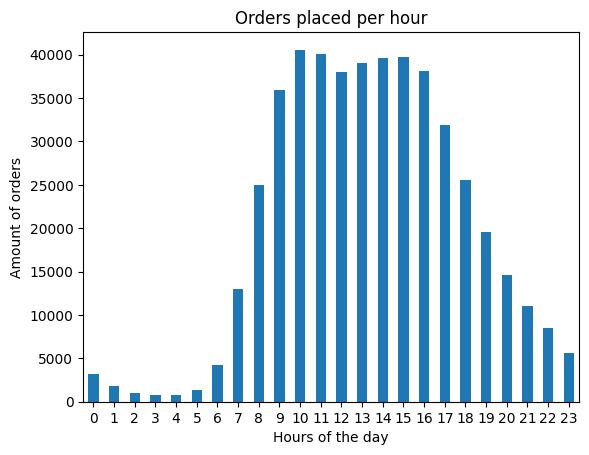

In [39]:
order_hour = orders['order_hour_of_day'].value_counts().sort_index()
print(order_hour)
order_hour.plot(title="Orders placed per hour", kind='bar',
                xlabel="Hours of the day", ylabel="Amount of orders", legend=False, rot=0)
plt.show()

I created a variable named order_hour that stores the amount of orders placed for each hour of the day then sorted the values using value_counts and sort_index. After I created a bar chart that displays the values from the order_hour variable using the plot function from matplotlib. The graph shows most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM. 

Most orders occur between 9:00 AM and 5:00 PM, with peaks at 10:00 AM and 3:00 PM

### [A3] What day of the week do people shop for groceries?

To figure out what day of the week people shop for groceries, analyze the order_dow column in the orders dataset. Use .value_counts() to count the number of orders for each day of the week, and then sort the results by the day index to maintain the correct order.

Visualize the data with a bar plot to clearly observe shopping patterns across the days of the week.

0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64


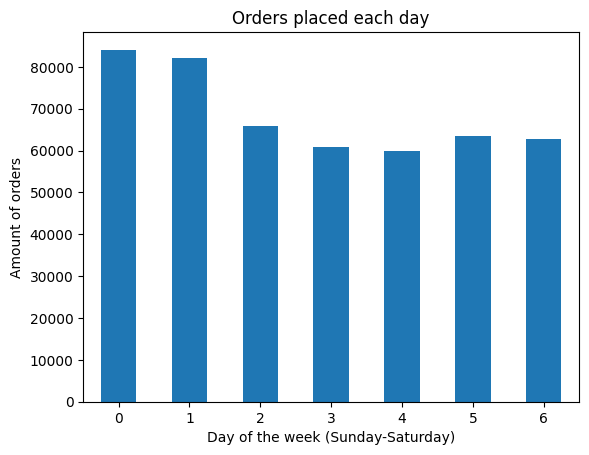

In [40]:
dow_count = orders['order_dow'].value_counts().sort_index()
print(dow_count)
dow_count.plot(title="Orders placed each day", kind='bar',
               xlabel="Day of the week (Sunday-Saturday)", ylabel="Amount of orders", legend=False, rot=0)
plt.show()

I created a variable named dow_hour that stores the amount of orders placed for each day of the week then sorted the values using value_counts and sort_index. After I created a bar chart that displays the values from the dow_hour variable using the plot function from matplotlib. The graph shows that Sunday and Monday are the peak days with the most orders.

The data dictionary does not state which integer corresponds to which day of the week. Assuming Sunday = 0, then people place more orders at the beginning of the week (Sunday and Monday).

### [A4] How long do people wait until placing another order?

To understand how long people wait before placing another order, analyze the days_since_prior_order column in the orders dataset. Use .value_counts() to count how many orders were placed for each interval of days, then sort the results by the number of days for clarity.

Visualize the data using a bar plot to observe patterns in ordering frequency over time.

0      9589
1     20179
2     27138
3     30224
4     31006
5     30096
6     33930
7     44577
8     25361
9     16753
10    13309
11    11467
12    10658
13    11737
14    13992
15     9416
16     6587
17     5498
18     4971
19     4939
20     5302
21     6448
22     4514
23     3337
24     3015
25     2711
26     2640
27     2986
28     3745
29     2673
30    51337
Name: days_since_prior_order, dtype: int64


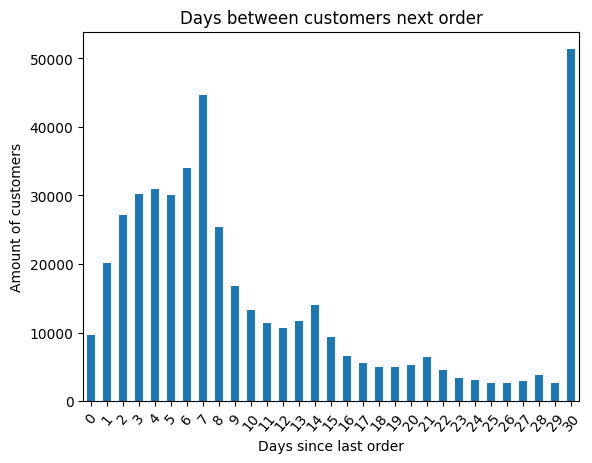

In [41]:
order_days = orders['days_since_prior_order'].value_counts().sort_index()
order_days.index = order_days.index.astype('int')
print(order_days)
order_days.plot(title="Days between customers next order", kind='bar',
                xlabel="Days since last order", ylabel="Amount of customers", legend=False, rot=50)
plt.show()

I created a variable named order_days that stores the amount of customers and how long they wait until their next order, then sorted the values using value_counts and sort_index. After I created a bar chart that displays the values from the order_days variable using the plot function from matplotlib. The graph shows most customers order between 2 and 10 days after their last order with the peak being at the 7 day mark or once weekly.

The 0 values probably correspond to customers who placed more than one order on the same day.

The max value of 30 days and the high spike at that value is puzzling though. The spike might be explained by people who set up recurring subscriptions to automatically order once a month. But that doesn't explain why there are no values above 30 days. I would expect many customers to place orders less often than once a month. Maybe those customers were intentionally excluded from the dataset.

Disregarding the spike at 30 days, most people wait between 2 to 10 days in between orders. The most common wait time is 7 days. In other words, it's common for people to place weekly grocery orders. Interestingly, in the tail of the distribution we also see small spikes at 14, 21, and 28 days. These would correspond to orders every 2, 3, or 4 weeks.

# [B] Medium (must complete all to pass)

### [B1] Is there a difference in `'order_hour_of_day'` distributions on Wednesdays and Saturdays? Plot the bar charts for both days and describe the differences that you see.

To determine if there's a difference in the `order_hour_of_day` distributions on Wednesdays and Saturdays, follow these steps:

1. **Create masks** for Wednesday (`order_dow == 3`) and Saturday (`order_dow == 6`) to filter the orders data.
2. **Count the order hours** for each day using `.value_counts()` and sort them by hour with `.sort_index()` for clarity.
3. **Combine the counts** for both days into a single DataFrame using `pd.concat()`, and label the columns for easier interpretation.

After preparing the data, plot bar charts for both days to visually compare the distribution of order times. Look for patterns such as peaks or differences in the busiest times throughout the day.

In [42]:
wed_orders = orders[orders['order_dow'] == 3]
sat_orders = orders[orders['order_dow'] == 6]

I created a filter for Wednesday and Saturday using there index positions in the order_dow column within the orders dataframe then assigned them to a variable wed_orders and sat_orders.

In [43]:
wed_count = wed_orders['order_hour_of_day'].value_counts().sort_index()
sat_count = sat_orders['order_hour_of_day'].value_counts().sort_index()
print(wed_count, sat_count)

0      373
1      215
2      106
3      101
4      108
5      170
6      643
7     1732
8     3125
9     4490
10    5026
11    5004
12    4688
13    4674
14    4774
15    5163
16    4976
17    4175
18    3463
19    2652
20    1917
21    1450
22    1154
23     718
Name: order_hour_of_day, dtype: int64 0      464
1      254
2      177
3      125
4      118
5      161
6      451
7     1619
8     3246
9     4311
10    4919
11    5116
12    5132
13    5323
14    5375
15    5188
16    5029
17    4295
18    3338
19    2610
20    1847
21    1473
22    1185
23     893
Name: order_hour_of_day, dtype: int64


Using the two variables(wed_count, sat_count) for orders on Wednesday and Saturday I applied the value_counts and sort_index to the order_hour_of_day columns within the filtered data to see the frequency of orders for each hour of the day for only Wednesday and Saturday.

In [44]:
ws_counts = pd.concat([wed_count, sat_count], axis='columns')
ws_counts.columns = ['wed_orders', 'sat_orders']
print(ws_counts)

    wed_orders  sat_orders
0          373         464
1          215         254
2          106         177
3          101         125
4          108         118
5          170         161
6          643         451
7         1732        1619
8         3125        3246
9         4490        4311
10        5026        4919
11        5004        5116
12        4688        5132
13        4674        5323
14        4774        5375
15        5163        5188
16        4976        5029
17        4175        4295
18        3463        3338
19        2652        2610
20        1917        1847
21        1450        1473
22        1154        1185
23         718         893


I combined both variables to display the frequency of orders for each hour of the day but only for Wednesday and Saturday.

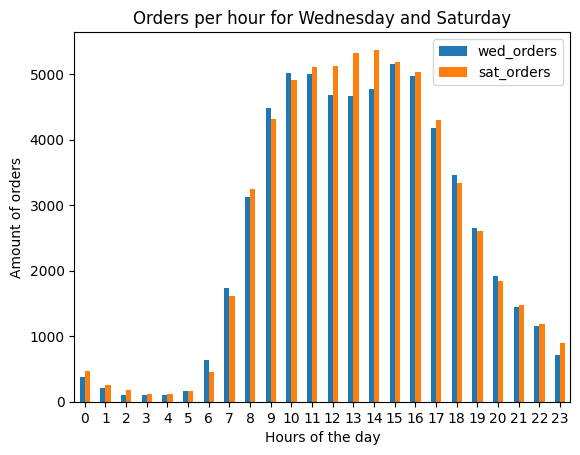

In [45]:
ws_counts.plot(title='Orders per hour for Wednesday and Saturday',
               xlabel="Hours of the day", ylabel="Amount of orders", kind='bar', rot=0)
plt.show()

I used the combined data variable ws_count to create a bar chart using plot. The graph shows Wednesday has a small dip between 11:00 AM and 1:00 PM, where most orders take place between 8:00 AM and 6:00 PM.

There's a small dip from 11h to 13h on Wednesdays. This dip is absent on Saturdays. Maybe this dip can be attributed to people who don't use Instacart because they have lunch somewhere between 11h and 13h.

### [B2] What's the distribution for the number of orders per customer?

To explore the distribution of the number of orders per customer:

1. **Group the data** by `user_id` to calculate the total number of orders for each customer. Use `.groupby('user_id')` and count the `order_id` for each group.
2. **Sort the results** using `.sort_values()` for better readability.
3. **Visualize the distribution** using a histogram to observe how many orders most customers typically place.

Adjust the number of bins in the histogram to refine the visualization and better capture the pattern.

In [46]:
count_id = orders.groupby('user_id')['order_id'].count().sort_values()
print(count_id)

user_id
152331     1
139876     1
60408      1
139873     1
139871     1
          ..
66664     24
148162    24
78375     25
193164    26
149605    28
Name: order_id, Length: 157437, dtype: int64


I created a variable named count_id that stores values for the orders dataframe grouping by the user_id column and counting the number of order ids associated with the user id, then sorted values in ascending order using sort_values.

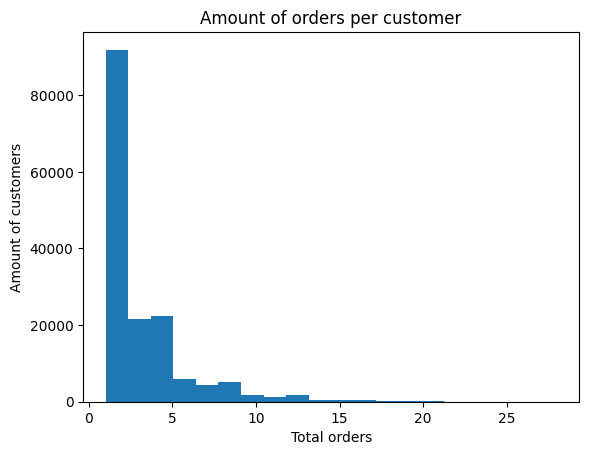

In [47]:
count_id.plot(title="Amount of orders per customer", kind='hist', bins=20)
plt.xlabel('Total orders')
plt.ylabel('Amount of customers')
plt.show()

I used the count_id variable to make a histogram to show the amount of orders per customers based on their user_id. The graph shows a sharp decrease after 1 meaning most customers have only ordered once.

Most customers in the dataset have placed between 1 and 10 orders, with number of orders per customer sharply decreasing after just 1 order.

### [B3] What are the top 20 popular products (display their id and name)?

To identify the top 20 most popular products:

1. **Merge the datasets**: Combine `order_products` and `products` on `product_id` to access both the product IDs and names in a single DataFrame.
2. **Group the data**: Group by both `product_id` and `product_name` to aggregate the order counts for each product using `.size()`.
3. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their popularity.
4. **Display the top 20**: Use `.head(20)` to focus on the most frequently ordered products.
5. **Visualize the results**: Create a bar chart to highlight the top products and their order counts.

This will give you a clear view of the most popular products and their ranking.


In [48]:
both_products = order_products.merge(products, on='product_id')
print(both_products)

         order_id  product_id  add_to_cart_order  reordered  \
0         2141543       11440                 17          0   
1          147172       11440                  7          1   
2         3341719       11440                  4          1   
3         1938779       11440                  8          1   
4         1728338       11440                 23          0   
...           ...         ...                ...        ...   
4524190    267402       45226                 14          0   
4524191   2621676       25201                 10          0   
4524192    937623       49153                  2          0   
4524193    532895        8182                  1          0   
4524194   3132243       40024                  1          0   

                               product_name  aisle_id  department_id  
0            chicken breast tenders breaded       129              1  
1            chicken breast tenders breaded       129              1  
2            chicken breast te

I created a new variable named both_products that merged the order_products and products dataframes on the Product_id column using the merge function then printed the results.

In [49]:
grp = both_products.groupby(['product_id', 'product_name']).size(
).sort_values(ascending=False).head(20)
print(grp)

product_id  product_name            
24852       banana                      66050
13176       bag of organic bananas      53297
21137       organic strawberries        37039
21903       organic baby spinach        33971
47209       organic hass avocado        29773
47766       organic avocado             24689
47626       large lemon                 21495
16797       strawberries                20018
26209       limes                       19690
27845       organic whole milk          19600
27966       organic raspberries         19197
22935       organic yellow onion        15898
24964       organic garlic              15292
45007       organic zucchini            14584
39275       organic blueberries         13879
49683       cucumber kirby              13675
28204       organic fuji apple          12544
5876        organic lemon               12232
8277        apple honeycrisp organic    11993
40706       organic grape tomatoes      11781
dtype: int64


Using the merged dataframe variable(both_products) I created a new variable called grp and used groupby to group the product_id and product_name column. Then used the size function to count how often each product is sold, using the head function to only display the top 20 products

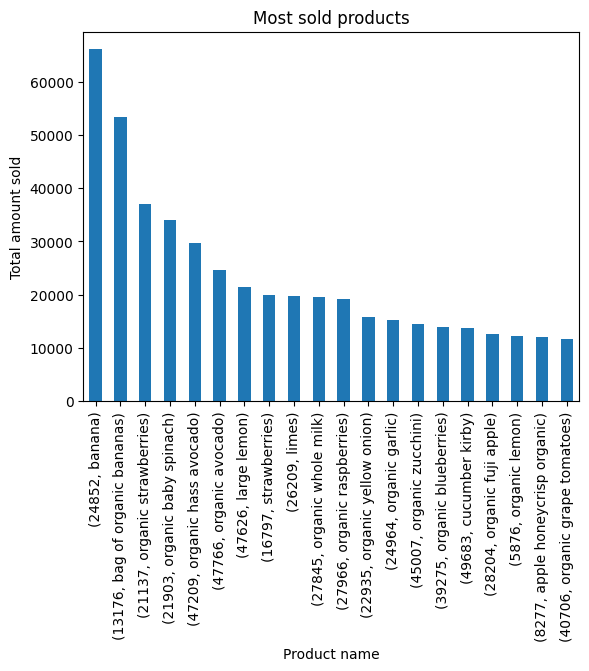

In [50]:
grp.plot(kind='bar', title="Most sold products",
         xlabel='Product name', ylabel='Total amount sold', rot=90)
plt.show()

Using the grp variable I created a bar chart that shows the most ordered products. The graph shows that bananas are the most ordered product and the top 20 products all are produce or whole milk.

The top 20 items are all produce, except for the milk. Looks like people want delicious and nutritious!

# [C] Hard (must complete at least two to pass)

### [C1] How many items do people typically buy in one order? What does the distribution look like?
To analyze how many items people typically buy in one order:

1. **Group the data** by `order_id` and count the number of products (`product_id`) in each order using `.count()`. This gives the number of items in each order.
2. **Aggregate the counts**: Use `.value_counts()` to determine how frequently different order sizes occur, and then sort the results with `.sort_index()` to organize by the number of items.
3. **Visualize the distribution**: Use a bar plot to show the frequency of orders for each size, with the x-axis representing the number of items and the y-axis representing the number of orders.

This will help you understand the typical size of a grocery order and identify any trends in purchasing behavior.

In [51]:

grp_order = order_products.groupby('order_id')['product_id'].count()
print(grp_order)

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64


I created a new variable called grp_order that uses the order_products dataframe to group the order_id column and counts the total product_id to determine how many products are in each order.

In [52]:

grp_sort = grp_order.value_counts().sort_index()
print(grp_sort)

1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: product_id, Length: 90, dtype: int64


I created a new variable named grp_sort I used value_counts to determine the how many items customers typically buy.

Most of the order numbers are in the tail of the distribution. To get a better look at the non-tail part, let's choose a value in the tail as a cutoff and just plot order with fewer than that many items. An order size of 35 items is far enough into the tail for this.

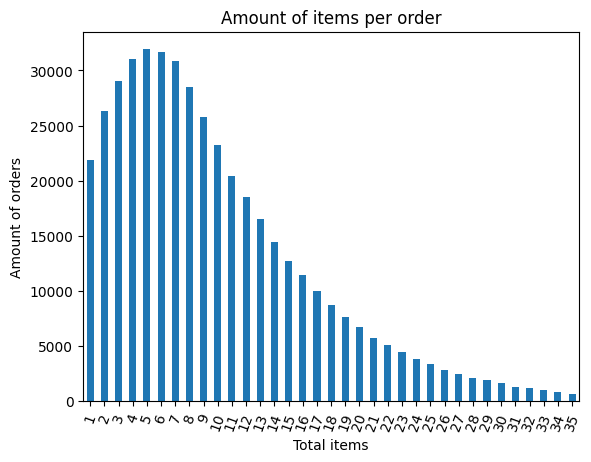

In [53]:
filtered_grp = grp_sort[grp_sort.index <= 35]
filtered_grp.plot(title="Amount of items per order", xlabel="Total items",
                  ylabel="Amount of orders", kind='bar', legend=False, rot=70)
plt.show()

I created a new vaiable called filtered_grp that filters the grp_sort variable to only show the amount of orders for customers with 35 items or less. Then used the filtered_grp variable to create a bar chart, showing most customer orders typically have between 1 and 20 items with 5 and 6 items being the peaks.

The typical order contains 5 or 6 items, with most orders having between 1 and 20 items.

### [C2] What are the top 20 items that are reordered most frequently (display their names and product IDs)?

To find the top 20 most frequently reordered items:

1. **Filter the data**: Use `order_products['reordered'] == 1` to isolate only the products that have been reordered.
2. **Merge the datasets**: Combine the filtered `order_products` with the `products` dataset on `product_id` to get both the product names and IDs.
3. **Group the data**: Group by both `product_id` and `product_name` to calculate how many times each product was reordered, using `.size()`.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank the products by reorder frequency.
5. **Display the top 20**: Use `.head(20)` to focus on the most frequently reordered products.
6. **Visualize the data**: Create a bar chart to showcase the top reordered items and their frequencies.

This process highlights the products that customers consistently return to and reorder.

In [54]:
reorder = order_products[order_products['reordered'] == 1]
print(reorder)

         order_id  product_id  add_to_cart_order  reordered
1          567889        1560                  1          1
2         2261212       26683                  1          1
3          491251        8670                 35          1
4         2571142        1940                  5          1
5         2456893       21616                  4          1
...           ...         ...                ...        ...
4544999   1622300       24852                  1          1
4545000   1125324       40600                  6          1
4545002    577211       15290                 12          1
4545004    692640       47766                  4          1
4545005    319435         691                  8          1

[2683838 rows x 4 columns]


I created a new variable named reorder and filtered the order_products dataframe by the reordered column to only show rows where the reordered column equals 1. Showing only rows that are reorders.

In [55]:
reorder_grp = reorder.merge(products, on='product_id')
print(reorder_grp)

         order_id  product_id  add_to_cart_order  reordered  \
0          567889        1560                  1          1   
1          761899        1560                  2          1   
2         1388514        1560                  8          1   
3         2629631        1560                  1          1   
4          866921        1560                  6          1   
...           ...         ...                ...        ...   
2674347   1338379       33506                  3          1   
2674348    191894       27878                  3          1   
2674349   3041739       31751                 14          1   
2674350    949244       24384                 18          1   
2674351   1078099       47673                 11          1   

                                              product_name  aisle_id  \
0                                               bag of ice        37   
1                                               bag of ice        37   
2                          

I created a new variable named reorder_grp that uses the reorder variable to merge with the products dataframe based on the product_id column.

In [56]:
product_grp = reorder_grp.groupby(
    ['product_id', 'product_name']).size().sort_values(ascending=False).head(20)
print(product_grp)

product_id  product_name            
24852       banana                      55763
13176       bag of organic bananas      44450
21137       organic strawberries        28639
21903       organic baby spinach        26233
47209       organic hass avocado        23629
47766       organic avocado             18743
27845       organic whole milk          16251
47626       large lemon                 15044
27966       organic raspberries         14748
16797       strawberries                13945
26209       limes                       13327
22935       organic yellow onion        11145
24964       organic garlic              10411
45007       organic zucchini            10076
49683       cucumber kirby               9538
28204       organic fuji apple           8989
8277        apple honeycrisp organic     8836
39275       organic blueberries          8799
5876        organic lemon                8412
49235       organic half & half          8389
dtype: int64


I created a new variable named product_grp that groups the reorder variable by the product_id and product_name columns, using the size function to count the product ids and product names to determine how many times each item has been reordered. Then using the head function to only display the top 20.

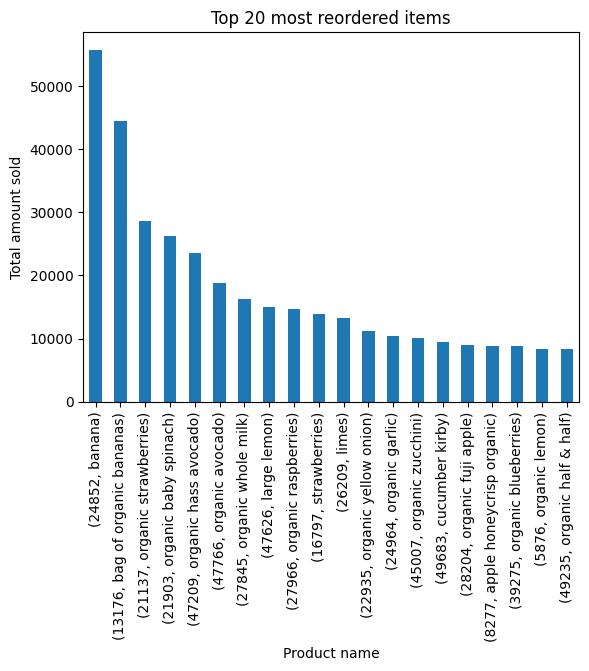

In [57]:
product_grp.plot(kind='bar', title='Top 20 most reordered items',
                 xlabel='Product name', ylabel='Total amount sold', legend=False)
plt.show()

Using the product_grp variable I created a bar chart using plot from matplotlib to display the top 20 most reordered products, showing the top 20 reordered items are produce and dairy with bananas being the most reordered.

It looks like produce and dairy comprise the most reordered products as well. It makes sense that perishables would be the most reordered items.

### [C3] For each product, what proportion of its orders are reorders?

To calculate the proportion of orders for each product that are reorders:

1. **Merge the datasets**: Combine `order_products` with the `products` dataset to access product names and IDs in the same DataFrame.
2. **Group the data**: Group by `product_id` and `product_name` to isolate each product's order history.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to compute the proportion of orders for each product that were reorders. The value represents the reorder rate.
4. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to organize the grouped data into a readable DataFrame.
6. **Optional Sorting**: Sort the results by `product_id` or another column for better clarity.

This approach provides insights into how frequently each product is reordered, helping identify customer favorites or staples.


### [C4] For each customer, what proportion of their products ordered are reorders?

To calculate the proportion of products reordered by each customer:

1. **Merge the datasets**: Combine `order_products` with `orders` to link order and customer information.
2. **Group the data**: Group by `user_id` to focus on each customer's ordering behavior.
3. **Calculate the mean of `reordered`**: Use `.mean()` on the `reordered` column to determine the proportion of products reordered by each customer.
4. **Sort the results**: Use `.sort_values(ascending=False)` to identify customers with the highest reorder rates.
5. **Convert to a DataFrame**: Use `.reset_index()` to format the grouped data into a structured DataFrame for further analysis.

This analysis reveals the extent to which individual customers reorder products, providing insights into customer loyalty and preferences.


### [C5] What are the top 20 items that people put in their carts first?

To identify the top 20 items that people most frequently add to their carts first:

1. **Merge the datasets**: Combine `order_products` with `products` to link product names and IDs.
2. **Filter the data**: Focus on rows where `add_to_cart_order` equals 1, indicating the first item added to the cart.
3. **Group the data**: Group by `product_id` and `product_name` to aggregate the count of how often each product was the first in a cart.
4. **Count occurrences**: Use `.count()` to calculate the total number of times each product was the first added.
5. **Sort the results**: Use `.sort_values(ascending=False)` to rank products by their first-in-cart frequency.
6. **Display the top 20**: Use `.head(20)` to extract the most popular first-in-cart items.

This provides insights into which products customers prioritize in their shopping process.


The products that are most often placed into the cart first are produce, dairy, and beverages such as soda or water. I couldn't really say why that is without experience using Instacart because this could have more to do with app design than properties of the products. I do notice that there is considerable overlap between this result and the previous result for most popular and most reordered item types. It could simply be that the app prioritizes popular items as the first suggested purchases, so it happens to be more convenient for customers to place these items in their cart first.